In [1]:
import fsspec; 
import xarray as xr
import torch
import xesmf as xe
import matplotlib.pyplot as plt
import numpy as np
import torch

fs = fsspec.filesystem("s3", profile="osn", client_kwargs={"endpoint_url": "https://nyu1.osn.mghpcc.org"})
storage_options = {"profile": "osn", "client_kwargs": {"endpoint_url": "https://nyu1.osn.mghpcc.org"}}


In [2]:
data_reference = xr.open_zarr("s3://emulators/jbusecke/ocean_emulators/OM4/OM4_raw_test.zarr", storage_options=storage_options)
grid_reference = xr.open_zarr("s3://emulators/am16581/ocean_static_no_mask_table.zarr", storage_options=storage_options)
data_reference['areacello'] = grid_reference['areacello']
data_reference = data_reference.set_coords('areacello')
data_reference['areacello_cu'] = grid_reference['areacello_cu']
data_reference = data_reference.set_coords('areacello_cu')
data_reference['areacello_cv'] = grid_reference['areacello_cv']
data_reference = data_reference.set_coords('areacello_cv')

In [10]:
data_processed = xr.open_zarr("s3://emulators/am16581/om4_halfdeg_testrun.zarr", storage_options=storage_options)
# data_processed = xr.open_zarr('/pscratch/sd/a/asubel/Ocean_Emulator/Data/om4_halfdeg.zarr/')

shape_processed = (data_processed.y.size, data_processed.x.size)

try:
    target_grid_path = f"s3://emulators/am16581/grids/gaussian_grid_{shape_processed[0]}_by_{shape_processed[1]}.zarr"
    target_grid = xr.open_zarr(target_grid_path, storage_options=storage_options)
    target_grid = target_grid.rename(
            {
                "grid_x": "x_b",
                "grid_y": "y_b",
                "grid_xt": "x",
                "grid_yt": "y",
                "grid_lon": "lon_b",
                "grid_lat": "lat_b",
                "grid_lont": "lon",
                "grid_latt": "lat",
            }
        ).compute()
    dx = target_grid['lon_b'].diff('x_b')[:-1]
    dy = target_grid['lat_b'].diff('y_b')[:,:-1]
    data_processed['dx'] = (['y','x'],dx.values)
    data_processed = data_processed.set_coords('dx')    
    data_processed['dy'] = (['y','x'],dy.values)
    data_processed = data_processed.set_coords('dy')    
    data_processed['latitude'] = (['y','x'],target_grid['lat'].values)
except:
    raise ValueError(f'Grid for shape {shape_processed} does not exist')


try:
    data_processed.areacello
except:
    data_processed['areacello'] = (['y','x'],xe.util.cell_area(target_grid).values)
    data_processed = data_processed.set_coords('areacello')
        
data_reference = data_reference.sel(time=slice(data_processed.time.values[0],data_processed.time.values[-1]))

/global/homes/a/asubel/.conda/envs/NERSC_Updated/lib/python3.13/site-packages/dask/array/core.py:4997: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(
/global/homes/a/asubel/.conda/envs/NERSC_Updated/lib/python3.13/site-packages/dask/array/core.py:4997: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(
/global/homes/a/asubel/.conda/envs/NERSC_Updated/lib/python3.13/site-packages/dask/array/core.py:4997: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(
/global/homes/a/asubel/.conda/envs/NERSC_Updated/lib/python3.13/site-packages/dask/array/core.py:4997: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(
/global/homes/a/asubel/.conda/envs/NERSC_Updated/lib/python3.13/site-packages/dask/array/core.py:4997: PerformanceWarning: Increasing number of chunks by factor of 10
  result = blockwise(
/global/homes/a/asubel/.conda/envs/NERSC_Updated/lib/py

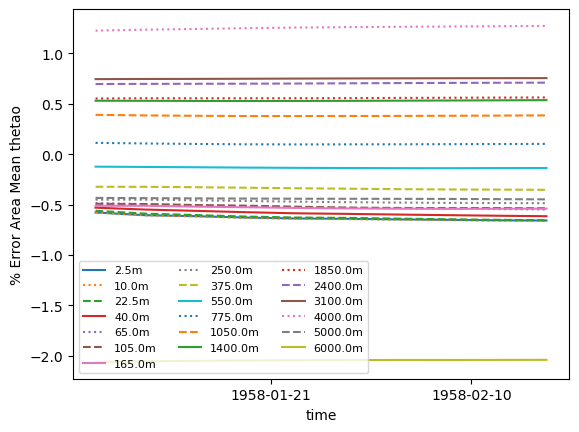

In [11]:
window_for_comparison = slice(0,25)
linestyles = ['-',':','--']
var_to_eval = 'thetao'
horizontal_dims = [i for i in data_reference[var_to_eval].dims if i not in ['lev', 'time']]
if horizontal_dims == ['yh','xh']:
    ref_areacello = data_reference['areacello']
elif horizontal_dims == ['yh','xq']:
    ref_areacello = data_reference['areacello_cu']    
elif horizontal_dims == ['yq','xh']:
    ref_areacello = data_reference['areacello_cv']   
else:
    raise ValueError('Areacello does not exist for this cell point')

for i in range(data_reference.lev.size):
    wet_ref = data_reference[var_to_eval].isel(time= 0,lev =i)*0+1

    ref_mean = (data_reference[var_to_eval].isel(time= window_for_comparison,lev =i)*ref_areacello).sum(horizontal_dims)/(wet_ref*ref_areacello).sum(horizontal_dims)
    wet_processed = data_processed[var_to_eval+'_'+str(i)].isel(time= 0)*0+1
    processed_mean = (data_processed[var_to_eval+'_'+str(i)].isel(time= window_for_comparison)*data_processed.areacello).sum(['x','y'])/(wet_processed*data_processed.areacello).sum(['x','y'])
    percent_error = ((processed_mean-ref_mean)/ref_mean)*100
    percent_error = percent_error.assign_attrs(long_name = '% Error Area Mean ' + var_to_eval)
    percent_error.plot(label = str(data_reference['lev'][i].values) +'m',ls = linestyles[i%len(linestyles)])
    plt.legend(fontsize = 8, ncols = 3)
    plt.title('')

Text(0, 0.5, 'Nino 3.4 Anomaly [$^\\circ C$]')

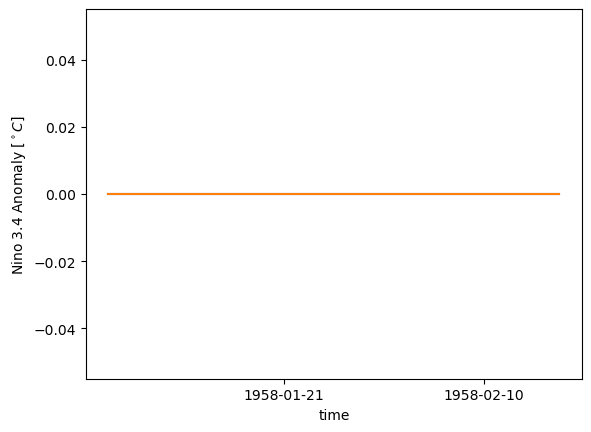

In [12]:
# Requires a longer dataset for meaningful computation
# Here we check that the data processing leaves the data unshifted by checking a measure of varibility that should not be changed

window_for_comparison = slice(0,73*5)

def calculate_nino34_index(dataset, horizontal_dims):
    if dataset[horizontal_dims[1]].min().values>=0:
        region = {
                        'lat_min': -5, 'lat_max': 5,
                        'lon_min': 190, 'lon_max': 240} 
    else:
        region = {
                        'lat_min': -5, 'lat_max': 5,
                        'lon_min': 190-360, 'lon_max': 240-360}  
        
    field_regional = dataset.sel({
        horizontal_dims[0]:slice(region['lat_min'], region['lat_max']),
        horizontal_dims[1]:slice(region['lon_min'], region['lon_max']),
        }
    )
    
    areacello_regional = field_regional.areacello
    

    regional_mean_ts = (field_regional * areacello_regional).sum( horizontal_dims, skipna=True) / areacello_regional.sum(horizontal_dims)
    
    climatology = regional_mean_ts.groupby('time.day').mean('time', skipna=True)
    anomaly_ts = regional_mean_ts.groupby('time.day') - climatology
        
    return anomaly_ts.compute()

horizontal_dims = [i for i in data_reference['thetao'].dims if i not in ['lev', 'time']]

nino_ref = calculate_nino34_index(data_reference['thetao'].isel(time = window_for_comparison,lev=0),
                                    horizontal_dims,
                                   )
nino_processed = calculate_nino34_index(data_processed['thetao_0'].isel(time = window_for_comparison),
                                ['y','x'],
                               )                                   

nino_ref.plot(label= 'Nino 3.4 Ref')
nino_processed.plot(label= 'Nino 3.4 Processed')
plt.ylabel(r'Nino 3.4 Anomaly [$^\circ C$]')

In [13]:
LAT_BOUNDS = (-40, 35)
LON_BOUNDS = (180, 243)

def _detrend_linear_torch(data):
    """
    Removes a linear plane of best fit from 4D (B, C, H, W) data.
    """
    B, C, H, W = data.shape
    device = data.device
    dtype = data.dtype
    
    y_coords = torch.linspace(-1, 1, H, device=device, dtype=dtype)
    x_coords = torch.linspace(-1, 1, W, device=device, dtype=dtype)
    Y, X = torch.meshgrid(y_coords, x_coords, indexing='ij')
    
    A = torch.stack([X.flatten(), Y.flatten(), torch.ones_like(X).flatten()], dim=1)
    
    B_prime = B * C
    data_flat = data.reshape(B_prime, H * W)
    

    coeffs, _, _, _ = torch.linalg.lstsq(A, data_flat.T)

    plane = (A @ coeffs.permute(1, 0).unsqueeze(-1)).reshape(B_prime, H, W)
    
    detrended_data = data.reshape(B_prime, H, W) - plane
    
    return detrended_data.reshape(B, C, H, W)


def compute_isotropic_spectrum_torch(data, dx=1.0, dy=1.0, num_bins=None, n_factor = 4,
                                     remove_mean=True, detrend=None, window='Hann',
                                     truncate=True, cutoff_before_bins: bool = True):
    """
    Computes the isotropic 1D power spectrum from 2D (H,W), 3D (B,H,W),
    or 4D (B,C,H,W) data. Matches `xrft.isotropic_power_spectrum(scaling="density")`.

    The output spectrum is computed for each batch and channel element.

    Parameters:
    ----------
    data : torch.Tensor
        Input data tensor. Can be 2D, 3D, or 4D.
    dx : float, optional
        Grid spacing in the x-dimension.
    dy : float, optional
        Grid spacing in the y-dimension.
    num_bins : int, optional
        Number of bins. If None, defaults to min(H, W) // n_factor.
    n_factor : int, optional
        Factor to determine number of bins.
    remove_mean : bool, optional
        If True, removes spatial mean. Overridden by `detrend`.
    detrend : str, optional
        'linear' or 'constant'.
    window : str, optional
        'hann' or 'Hann'.
    truncate : bool, optional
        If True, truncates spectrum at the smallest Nyquist frequency.
    cutoff_before_bins: bool, optional
        If True, truncates the spectrum after already computing the bin locations. Matches xrft
    Returns:
    -------
    k_bins_centers : torch.Tensor
        1D tensor of bin center wavenumbers. Shape: (num_bins,)
    iso_spectrum : torch.Tensor
        1D tensor of the (k * P(k)) spectrum.
        Shape: (B, C, num_bins), (B, num_bins), or (num_bins,)
    """
    
    device = data.device
    dtype = data.dtype
    orig_dim = data.dim()
    
    if orig_dim == 2:
        data = data.reshape(1, 1, *data.shape)  
    elif orig_dim == 3:
        data = data.unsqueeze(1)                
    elif orig_dim != 4:
        raise ValueError("Input data must be 2D, 3D, or 4D (B, C, H, W)")
        
    B, C, H, W = data.shape
    B_prime = B * C 
    Lx = W * dx
    Ly = H * dy
    
    if num_bins is None:
        num_bins = min(H, W) // n_factor 

    if detrend == 'linear':
        data = _detrend_linear_torch(data)
    elif detrend == 'constant' or remove_mean:
        data = data - torch.mean(data, dim=(-2, -1), keepdim=True)

    if window and window.lower() == 'hann':
        win_y = torch.hann_window(H, device=device, dtype=dtype).unsqueeze(1)
        win_x = torch.hann_window(W, device=device, dtype=dtype).unsqueeze(0)
        win_2d = (win_y * win_x).reshape(1, 1, H, W)
        
        window_correction = torch.mean(win_2d**2).item()
        data = data * win_2d
    else:
        window_correction = 1.0

    fft_2d = torch.fft.rfft2(data, norm='forward')
    
    power_2d = torch.abs(fft_2d)**2
    power_2d = power_2d / window_correction
    
    psd_2d = power_2d * (Lx * Ly)
    
    k_x = torch.fft.rfftfreq(W, d=dx, device=device, dtype=dtype)
    k_y = torch.fft.fftfreq(H, d=dy, device=device, dtype=dtype)
    
    k_x_nyq = 1.0 / (2.0 * dx)
    k_y_nyq = 1.0 / (2.0 * dy)

    k_Y, k_X = torch.meshgrid(k_y, k_x, indexing='ij')
    k_mag = torch.sqrt(k_X**2 + k_Y**2)
    
    k_max_domain = k_mag.max()
    
    if truncate and cutoff_before_bins:
        k_max_cutoff = min(k_x_nyq, k_y_nyq)
        k_max = min(k_max_domain, k_max_cutoff)
    else:
        k_max = k_max_domain
        
    k_bins = torch.linspace(0, k_max, num_bins + 1, device=device, dtype=dtype)
    if truncate and not cutoff_before_bins:
        k_max_cutoff = min(k_x_nyq, k_y_nyq) 
        k_max = min(k_max_domain, k_max_cutoff)        
        k_bins = k_bins[k_bins<k_max_cutoff]
        num_bins = k_bins.numel()-1
    k_bins_centers = (k_bins[:-1] + k_bins[1:]) / 2

    k_mag_flat = k_mag.flatten()
    bin_edges = k_bins[1:-1] 
    
    bin_indices = torch.bucketize(k_mag_flat, bin_edges, right=True)
    
    N_flat = k_mag_flat.shape[0]
    psd_flat_batched = psd_2d.reshape(B_prime, N_flat)

    bin_indices_batched = bin_indices.expand(B_prime, -1)
    
    binned_psd_sum = torch.zeros(B_prime, num_bins, device=device, dtype=dtype)

    binned_psd_sum.scatter_add_(dim=1, index=bin_indices_batched, src=psd_flat_batched)
    
    binned_counts = torch.bincount(
        bin_indices, 
        minlength=num_bins
    )
    
    binned_counts_safe = binned_counts.float()
    binned_counts_safe[binned_counts_safe == 0] = torch.nan

    iso_psd_binned = binned_psd_sum / binned_counts_safe.unsqueeze(0)
    
    iso_spectrum = iso_psd_binned * k_bins_centers.unsqueeze(0)
    
    iso_spectrum = iso_spectrum.reshape(B, C, num_bins)
    
    iso_spectrum[..., 0] = torch.nan
    
    if orig_dim == 2:
        iso_spectrum = iso_spectrum.squeeze(0).squeeze(0) 
    elif orig_dim == 3:
        iso_spectrum = iso_spectrum.squeeze(1)            
    
    return k_bins_centers, iso_spectrum

<>:75: SyntaxWarning: invalid escape sequence '\k'
<>:75: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_203234/989888186.py:75: SyntaxWarning: invalid escape sequence '\k'
  plt.xlabel(f'Wavenumber $\kappa$ (1/ km)')


25725.376953125 25725.36328125
51730.648721281505 55581.29068617284


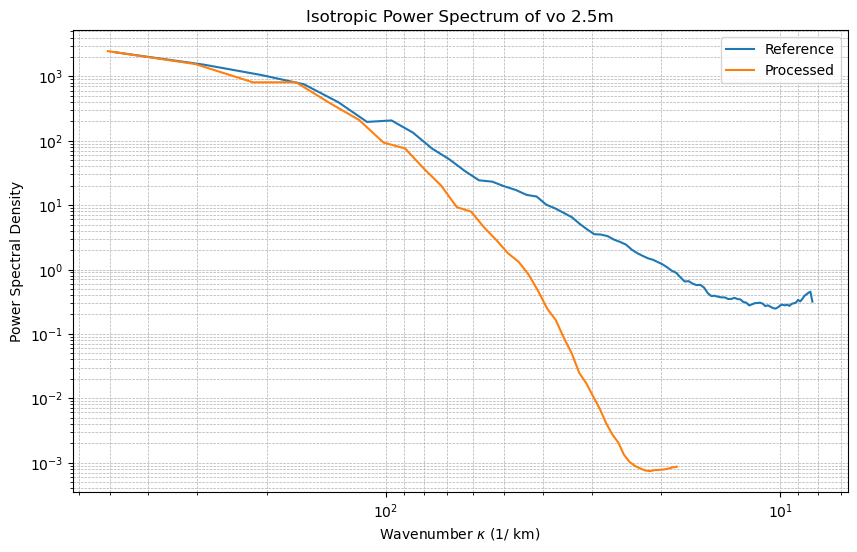

In [15]:
# Check the spectra to make sure we are not cutting off too much spatial information

var_to_eval = 'vo'
lev = 0
time_window = 10

R  = 6.378e6

horizontal_dims = [i for i in data_reference[var_to_eval].dims if i not in ['lev', 'time']]
if horizontal_dims == ['yh','xh']:
    dx_calc = grid_reference['dxt']
    dy_calc = grid_reference['dyt']
    lat_vals = grid_reference['geolat']
elif horizontal_dims == ['yh','xq']:
    dx_calc = grid_reference['dxCu']
    dy_calc = grid_reference['dyCu']
    lat_vals = grid_reference['geolat_u']    
elif horizontal_dims == ['yq','xh']:
    dx_calc = grid_reference['dxCv']
    dy_calc = grid_reference['dyCv']
    lat_vals = grid_reference['geolat_v']        
else:
    raise ValueError('Areacello does not exist for this cell point')

lon_slice = slice(180-360,243-360)
lat_slice = slice(-40,35)

dx_mean = float(dx_calc.sel({horizontal_dims[1]: lon_slice,horizontal_dims[0]: lat_slice}).mean().values)
dy_mean = float(dy_calc.sel({horizontal_dims[1]: lon_slice,horizontal_dims[0]: lat_slice}).mean().values)

print(dx_mean,dy_mean)
k_centers_ref, spectrum_ref = compute_isotropic_spectrum_torch(
    torch.as_tensor(data_reference[var_to_eval].isel(lev=lev,time=slice(None,time_window)).transpose('time',...).sel({horizontal_dims[1]: lon_slice,
                                                                                   horizontal_dims[0]: lat_slice}).fillna(0).values), 
    dx=dx_mean, 
    dy=dy_mean, 
    n_factor=2,
    detrend = 'linear',
    window = 'hann',
    cutoff_before_bins=False,
)

k_centers_ref = k_centers_ref.cpu().numpy()*1000*2*np.pi
spectrum_ref = spectrum_ref.cpu().numpy()

lon_slice = slice(180,243)
lat_slice = slice(-40,35)

dy_calc = (data_processed.dy/360)*2*np.pi*R
dx_calc = (data_processed.dx/360)*2*np.pi*np.cos((data_processed.latitude.values/360)*2*np.pi)*R

dx_mean = float(dx_calc.sel(x = lon_slice,y = lat_slice).mean().values)
dy_mean = float(dy_calc.sel(x = lon_slice,y = lat_slice).mean().values)
print(dx_mean,dy_mean)

k_centers_processed, spectrum_processed = compute_isotropic_spectrum_torch(
    torch.as_tensor(data_processed[var_to_eval+'_'+str(lev)].isel(time=slice(None,time_window)).transpose('time',...).sel(x = lon_slice,
                                                                                   y = lat_slice).fillna(0).values), 
    dx=dx_mean, 
    dy=dy_mean, 
    n_factor=2,
    detrend = 'linear',
    window = 'hann',
    cutoff_before_bins=False,
)

k_centers_processed = k_centers_processed.cpu().numpy()*1000*2*np.pi
spectrum_processed = spectrum_processed.cpu().numpy()


plt.figure(figsize=(10, 6))
plt.loglog(1/k_centers_ref, spectrum_ref.mean(0), '-', label='Reference')
plt.loglog(1/k_centers_processed, spectrum_processed.mean(0), '-', label='Processed')
plt.gca().invert_xaxis()
plt.xlabel(f'Wavenumber $\kappa$ (1/ km)')
plt.ylabel('Power Spectral Density')
plt.title('Isotropic Power Spectrum of ' + var_to_eval + ' ' + str(data_reference.lev.values[lev]) + 'm')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()